In [218]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import seaborn as sns
from spreadML import *
from api_calls import *
client = mongoConn()

Pinged your deployment. You successfully connected to MongoDB!


In [139]:
dfbets = get_db(client, 'withTheSpread', 'bets')
# convert week columns to float
for col in ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17']:
    dfbets[col] = dfbets[col].astype(float)
week = '4'
prev_weeks = [str(i) for i in range(1, int(week))]
dfbets

,_id,Team,Year,teamyearid,Bet,1,2,3,4,5,...,9,10,11,12,13,14,15,16,17,18
0,650a7f0f8f4441015a929519,Arizona Cardinals,2000,Arizona Cardinals-2000,SpreadScore,1.5,-2.0,NaN,-27.0,-3.5,...,-5.0,11.0,-4.5,-18.0,-18.0,-7.0,-49.0,9.0,-10.0,NaN
1,650a7f0f8f4441015a92951a,Arizona Cardinals,2001,Arizona Cardinals-2001,SpreadScore,NaN,-12.5,-17.0,15.5,-0.0,...,-1.5,5.0,10.0,16.0,-12.0,1.0,3.5,24.0,0.5,NaN
2,650a7f0f8f4441015a92951b,Arizona Cardinals,2002,Arizona Cardinals-2002,SpreadScore,-2.0,15.0,-5.5,17.0,8.0,...,-8.0,-24.0,-12.0,-11.5,-40.0,4.0,9.0,0.5,-16.5,NaN
3,650a7f0f8f4441015a92951c,Arizona Cardinals,2003,Arizona Cardinals-2003,SpreadScore,-14.5,-33.0,14.5,-12.5,-9.5,...,6.0,-6.0,-33.0,4.0,-20.5,-25.5,4.0,-2.5,8.5,NaN
4,650a7f0f8f4441015a92951d,Arizona Cardinals,2004,Arizona Cardinals-2004,SpreadScore,4.0,-3.0,8.0,27.5,-2.0,...,4.0,2.0,-22.0,-7.0,-8.0,-10.0,27.0,4.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2389,68c1f452339721a0d985e01c,Philadelphia Eagles,2023,Philadelphia Eagles-2023,Spread,1.0,-1.0,7.0,-4.0,2.5,...,2.0,NaN,7.0,0.5,-25.5,-25.5,-19.0,NaN,0.5,-15.0
2390,68c1f452339721a0d985e01d,Dallas Cowboys,2023,Dallas Cowboys-2023,Spread,36.5,17.0,-19.0,30.5,-29.5,...,-2.0,26.5,19.5,29.0,2.5,2.5,19.0,-17.0,-0.5,-2.5
2391,68c1f452339721a0d985e01e,New York Giants,2023,New York Giants-2023,Spread,-36.5,-1.5,-12.0,-22.0,-10.5,...,-22.5,-26.5,10.5,1.5,NaN,NaN,-0.5,-15.5,-0.5,-4.0
2392,68c1f452339721a0d985e01f,Buffalo Bills,2023,Buffalo Bills-2023,Spread,-8.5,19.0,29.5,24.5,-8.5,...,-5.0,-8.0,22.0,-0.5,NaN,NaN,6.5,17.0,1.0,-0.5


In [14]:
dfbets_spreadscore = dfbets[dfbets['Bet']=='SpreadScore']

In [216]:
dfbets_spreadscore[dfbets_spreadscore['4']<-5][['1','2','3']].agg(['mean','std','count'])
# dfbets_spreadscore[(dfbets_spreadscore[prev_weeks]<0).all(axis=1)][week].sign()
# dfbets_spreadscore[(dfbets_spreadscore[prev_weeks]>0).all(axis=1)][week].hist()

,1,2,3
mean,0.969008,-1.543210,0.852941
std,14.037150,13.093481,13.810479
count,242.000000,243.000000,238.000000


In [148]:
import numpy as np

sign_counts = np.sign(
    dfbets_spreadscore.loc[
        (dfbets_spreadscore[prev_weeks] > 0).all(axis=1),
        week
    ]
).value_counts().rename(index={-1: "negative", 0: "zero", 1: "positive"})

print(sign_counts)


4
negative    42
positive    31
Name: count, dtype: int64


In [42]:
dfbets_spreadscore[(dfbets_spreadscore['1']>5)
& (dfbets_spreadscore['2']>5)
& (dfbets_spreadscore['3']<-5)
][['4','5']].mean()

4    1.978261
5   -0.565217
dtype: float64

In [27]:
week = 3
dfbets[dfbets[str(week)]<0].groupby('Bet')[['1','2']].mean()

,1,2
Bet,,
OverUnder,-1.600000,-1.333333
Spread,-1.391781,-1.506868
SpreadScore,0.975852,-0.143466
spreads,0.700000,0.866667
spreadscore,0.700000,0.866667
totals,0.700000,0.866667


In [151]:
import numpy as np

def make_lstm_windows(Xs, y, lookback=3):
    """
    Build sliding windows for LSTM input.

    Parameters
    ----------
    Xs : list of DataFrames or Series
        Each X must have columns as week numbers (str or int).
        All Xs must have the same shape.
    y : DataFrame or Series
        Target values with same shape as Xs[0].
    lookback : int
        Number of weeks to look back.

    Returns
    -------
    X_tensor : np.ndarray, shape (samples, lookback, n_features)
        Tensor for LSTM input.
    y_out : np.ndarray, shape (samples,)
        Target values.
    """
    n_samples, n_weeks = Xs[0].shape
    n_features = len(Xs)

    X_tensor, y_out = [], []

    for row in range(n_samples):  # e.g. one team-season row
        for t in range(n_weeks - lookback):
            # collect one window across all features
            window = []
            for X in Xs:
                series = X.iloc[row, t:t+lookback].values
                window.append(series)
            # transpose so shape = (lookback, n_features)
            window = np.stack(window, axis=-1)
            X_tensor.append(window)
            y_out.append(y.iloc[row, t+lookback])

    return np.array(X_tensor), np.array(y_out)


weeks with tie spreadscore = 1007
Train: (5728, 3, 2) (5728,)
Val:   (1432, 3, 2) (1432,)
Test:  (1791, 3, 2) (1791,)


<Axes: ylabel='Density'>

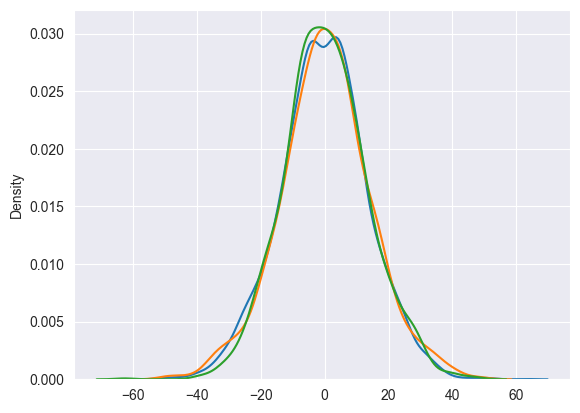

In [236]:
week = '5'
prev_weeks = [str(i) for i in range(1, int(week))]
# X1 = dfbets[dfbets['Bet']=='SpreadScore'][prev_weeks].reset_index(drop=True).fillna(0)
# X2 = dfbets[dfbets['Bet']=='Spread'][prev_weeks].reset_index(drop=True).fillna(0)
# y = dfbets[dfbets['Bet']=='SpreadScore'][str(week)].reset_index(drop=True).fillna(0)
# stack X1 and X2 as features
# X = np.stack([X1.values, X2.values], axis=-1)  # shape: (samples, timesteps, features)
# y = y.values  # shape: (samples,)
# First split off test set
# X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# # Then split train/validation
# X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

lstm_window_weeks = [str(i) for i in range(1, 17)]

X1 = dfbets[dfbets['Bet']=='SpreadScore'][lstm_window_weeks].reset_index(drop=True).fillna(0)
X2 = dfbets[dfbets['Bet']=='Spread'][lstm_window_weeks].reset_index(drop=True).fillna(0)
X3 = dfbets[dfbets['Bet']=='OverUnder'][lstm_window_weeks].reset_index(drop=True).fillna(0)
y = dfbets[dfbets['Bet']=='SpreadScore'][lstm_window_weeks].reset_index(drop=True).fillna(0)

X,y = make_lstm_windows([X1,X2,X3],y,lookback=3)
print(f'weeks with tie spreadscore = {len(y[y==0])}')
X = X[y!=0]
y = y[y!=0]
# first split off test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random.randint(1, 100 )
)

# then split train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=random.randint(1, 100)
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)



# print kde for y datasets
import pandas as pd
import seaborn as sns
sns.kdeplot(y_train, label='trainval')
sns.kdeplot(y_val, label='train')
sns.kdeplot(y_test, label='val')



In [248]:
dfbets[(dfbets['Year']==2024)]

,_id,Team,Year,teamyearid,Bet,1,2,3,4,5,...,9,10,11,12,13,14,15,16,17,18
2202,68c1e37b339721a0d985df5d,Baltimore Ravens,2024,Baltimore Ravens-2024,spreadscore,-4.0,-10.5,4.0,22.0,4.5,...,20.5,-2.0,-5.0,-5.0,NaN,4.0,-8.5,14.5,11.5,26.5
2203,68c1e37b339721a0d985df5e,Kansas City Chiefs,2024,Kansas City Chiefs-2024,spreadscore,4.0,-2.5,1.5,3.5,5.0,...,NaN,-1.5,-7.0,-10.5,-4.5,-5.5,-4.5,11.5,3.5,12.5
2204,68c1e37b339721a0d985df5f,Green Bay Packers,2024,Green Bay Packers-2024,spreadscore,-3.0,1.5,12.5,-7.0,6.5,...,-11.5,NaN,0.0,0.0,30.5,10.0,0.0,16.0,29.0,-4.0
2205,68c1e37b339721a0d985df60,Philadelphia Eagles,2024,Philadelphia Eagles-2024,spreadscore,3.0,-5.5,0.0,-20.0,NaN,...,1.5,30.0,1.0,1.0,18.0,8.5,-1.5,9.5,-6.5,31.5
2206,68c1e37b339721a0d985df61,Arizona Cardinals,2024,Arizona Cardinals-2024,spreadscore,0.5,33.5,-3.0,-30.5,10.5,...,21.5,28.0,NaN,NaN,-7.0,1.0,-13.0,9.5,-7.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2293,68c1e37b339721a0d985dfb8,Washington Commanders,2024,Washington Commanders-2024,spreads,-13.5,0.5,12.0,30.5,24.0,...,6.5,0.5,-1.0,-1.0,-4.5,21.5,NaN,4.0,6.5,8.5
2294,68c1e37b339721a0d985dfb9,Detroit Lions,2024,Detroit Lions-2024,spreads,2.5,-10.5,3.0,7.5,NaN,...,11.5,4.0,42.0,42.0,15.5,-1.0,0.0,-8.0,16.0,10.5
2295,68c1e37b339721a0d985dfba,Los Angeles Rams,2024,Los Angeles Rams-2024,spreads,-2.5,-33.5,6.0,-4.5,-6.5,...,4.5,-9.0,2.0,2.0,-18.0,5.5,3.0,12.5,13.0,NaN
2296,68c1e37b339721a0d985dfbb,New York Jets,2024,New York Jets-2024,spreads,-8.5,3.0,13.5,-8.5,-10.0,...,5.5,-28.0,-5.0,-5.0,NaN,-9.5,-4.0,6.0,-13.0,-23.5


In [237]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = X.shape[1]
features = X.shape[2]

model = models.Sequential([
    layers.Input(shape=(timesteps, features)),
    layers.LSTM(32, return_sequences=False),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)  # regression output
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])


In [238]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 187.3970 - mae: 10.7683 - val_loss: 201.0055 - val_mae: 10.9419
Epoch 2/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 187.0323 - mae: 10.7590 - val_loss: 200.8558 - val_mae: 10.9419
Epoch 3/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 186.8967 - mae: 10.7536 - val_loss: 201.3934 - val_mae: 10.9516
Epoch 4/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 186.9281 - mae: 10.7537 - val_loss: 200.9619 - val_mae: 10.9449
Epoch 5/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 186.8057 - mae: 10.7527 - val_loss: 200.8687 - val_mae: 10.9419
Epoch 6/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 186.8348 - mae: 10.7511 - val_loss: 200.8545 - val_mae: 10.9428
Epoch 7/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 186.6872 - mae: 10.7488 - val_loss: 200.8559 - val_mae: 10.9448
Epoch 8/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 186.5970 - mae: 10.7449 - val_loss: 200.8023 - val_mae: 10.9450
Epoch 9/

Test MSE: 172.839, Test MAE: 10.328
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
          y_true    y_pred
y_true  1.000000  0.011862
y_pred  0.011862  1.000000
y_true    0.430765
y_pred    0.005818
dtype: float64
0.4868788386376326
0.5952380952380952


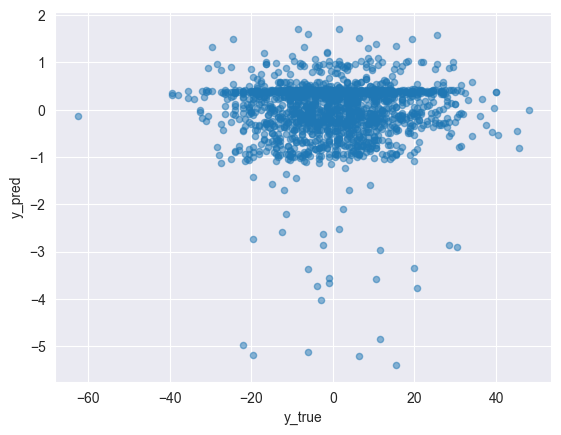

In [239]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {test_loss:.3f}, Test MAE: {test_mae:.3f}")

y_pred = model.predict(X_test)
test_pred = pd.DataFrame({'y_true': y_test.flatten(), 'y_pred': y_pred.flatten().round(2)})
print(test_pred.corr())
test_pred.plot(kind='scatter', x='y_true', y='y_pred', alpha=0.5)
# groupby to get means and counts

print(test_pred.mean())
# convert to sign of spread
print((np.sign(test_pred['y_true']) == np.sign(test_pred['y_pred'])).mean())
test_pred_conf = test_pred[test_pred['y_pred'].abs()>1]
print((np.sign(test_pred_conf['y_true']) == np.sign(test_pred_conf['y_pred'])).mean())

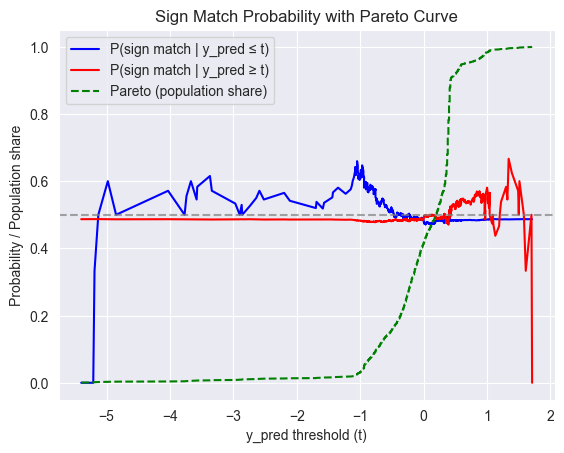

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# assume df has columns: y_pred, y_true
df = test_pred.copy()
df = df[df['y_true']!=0]
df["sign_match"] = np.sign(df["y_pred"]) == np.sign(df["y_true"])

# sort by y_pred
df = df.sort_values("y_pred").reset_index(drop=True)

# cumulative from left (≤)
cum_left = df["sign_match"].expanding().mean()

# cumulative from right (≥)
cum_right = df["sign_match"].iloc[::-1].expanding().mean()[::-1]

# Pareto curve (normalized population share, goes 0 → 1)
pareto = np.arange(1, len(df)+1) / len(df)

# plot everything on the same axis
plt.plot(df["y_pred"], cum_left, label="P(sign match | y_pred ≤ t)", color="blue")
plt.plot(df["y_pred"], cum_right, label="P(sign match | y_pred ≥ t)", color="red")
plt.plot(df["y_pred"], pareto, label="Pareto (population share)", color="green", linestyle="--")

plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
plt.xlabel("y_pred threshold (t)")
plt.ylabel("Probability / Population share")
plt.title("Sign Match Probability with Pareto Curve")
plt.legend()
plt.show()


In [241]:
test_pred[test_pred['y_pred']<-test_pred['y_pred'].quantile(.95)]['y_true'].apply(np.sign).agg(['mean','count','std'])

mean      -0.094170
count    223.000000
std        0.997796
Name: y_true, dtype: float64

In [242]:
test_pred['y_pred'].std()


0.6511279940605164

In [167]:
thresh = test_pred['y_pred'].std()*2
test_pred_conf = test_pred[test_pred['y_pred'].abs()>thresh]
print((np.sign(test_pred_conf['y_true']) == np.sign(test_pred_conf['y_pred'])).agg(['mean','count','std']))

mean       0.419580
count    143.000000
std        0.495225
dtype: float64


In [168]:
test_pred_conf

,y_true,y_pred
55,12.0,0.9
86,-7.5,0.7
89,-4.0,1.1
97,0.0,1.0
106,-4.0,0.7
...,...,...
1891,12.5,0.7
1913,10.0,1.1
1970,-10.0,0.7
1971,0.0,0.7


In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Filter rows where 'Bet' is 'SpreadScore'
spreadscore_df = dfbets[dfbets['Bet'] == 'SpreadScore'].copy()

# Select columns for last N weeks (n=5) and 'Team', 'Year'
n_weeks = 5
week = 10
weeks_to_use = [str(i) for i in range(week-n_weeks, week)]
columns_to_use = ['Team', 'Year'] + weeks_to_use

# Keep only relevant columns
filtered_df = spreadscore_df[columns_to_use].copy()

# Add indicator columns for NaN values (bye weeks)
for col in weeks_to_use:
    # filtered_df[f"{col}_isnull"] = filtered_df[col].isnull().astype(int)
    filtered_df[col] = filtered_df[col].astype(float)

# Add target column as the next week's spreadscore (shifted)
filtered_df['target'] = spreadscore_df[str(week)].shift(-1)

# Keep rows with target and feature data (allow NaNs for features)
filtered_df = filtered_df.dropna(subset=['target'])

# Final prepared dataset
print(filtered_df.head())
print(filtered_df.info())

# Define X (features) and y (target)
features = weeks_to_use
isnull_features = [f"{col}_isnull" for col in features]
final_features = features# + isnull_features

X = filtered_df[final_features]
y = filtered_df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize XGBoost model
model = XGBRegressor(n_estimators=200, learning_rate=0.05)

# Train model
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {rmse}")

# Feature importance
importance = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': final_features, 'Importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

                Team  Year    5     6     7     8    9 target
0  Arizona Cardinals  2000 -3.5   3.5 -16.5 -34.0 -5.0    5.0
1  Arizona Cardinals  2001 -0.0  10.0 -17.0  -7.0 -1.5  -24.0
2  Arizona Cardinals  2002  8.0   NaN  -0.5  -1.5 -8.0   -6.0
3  Arizona Cardinals  2003 -9.5  -1.5   NaN  10.0  6.0    2.0
4  Arizona Cardinals  2004 -2.0   NaN  14.5 -19.5  4.0   -4.0
<class 'pandas.core.frame.DataFrame'>
Int64Index: 653 entries, 0 to 732
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Team    653 non-null    object 
 1   Year    653 non-null    int64  
 2   5       588 non-null    float64
 3   6       570 non-null    float64
 4   7       565 non-null    float64
 5   8       570 non-null    float64
 6   9       561 non-null    float64
 7   target  653 non-null    object 
dtypes: float64(5), int64(1), object(2)
memory usage: 45.9+ KB
None
Root Mean Squared Error: 14.587403295235466
  Feature  Importance
3       8    0.23071

In [46]:
import numpy as np

def sign_agreement(y_true, y_pred):
    """
    Calculate the percentage of cases where the predicted and actual values share the same sign.

    Parameters:
    y_true (array-like): Actual target values.
    y_pred (array-like): Predicted values.

    Returns:
    float: Percentage of sign agreement.
    """
    # Convert actual and predicted values to their signs (-1, 0, or 1)
    true_sign = np.sign(y_true)
    pred_sign = np.sign(y_pred)

    # Compare the signs and calculate the agreement percentage
    agreement = np.mean(true_sign == pred_sign) * 100
    return agreement

# Example usage:
sign_accuracy = sign_agreement(y_test, y_pred)
print(f"Sign Agreement Accuracy: {sign_accuracy:.2f}%")

Sign Agreement Accuracy: 45.04%


In [89]:


# ===================== Feature Generation =====================
# Filter rows where 'Bet' is 'SpreadScore'
spreadscore_df = dfbets[dfbets['Bet'] == 'SpreadScore'].copy()


# Select columns for last N weeks (n=5) and 'Team', 'Year'
n_weeks = 5
week = 10
weeks_to_use = [str(i) for i in range(week - n_weeks, week)]
# columns_to_use = ['Team', 'Year'] + weeks_to_use
columns_to_use = ['Year'] + weeks_to_use

# Keep only relevant columns
filtered_df = spreadscore_df[columns_to_use].copy()

# Convert week columns to float
for col in weeks_to_use:
    filtered_df[col] = filtered_df[col].fillna(-999).astype(float)

# Add target column as the next week's spreadscore
filtered_df['target'] = spreadscore_df[str(week)]

# Drop rows where the target is NaN
filtered_df = filtered_df.dropna(subset=['target'])
filtered_df['target'] = filtered_df['target'].astype(float)

display(filtered_df.info())
# Final prepared dataset
features = weeks_to_use
X = filtered_df[features].values
y = filtered_df['target'].values



<class 'pandas.core.frame.DataFrame'>
Int64Index: 654 entries, 0 to 733
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    654 non-null    int64  
 1   5       654 non-null    float64
 2   6       654 non-null    float64
 3   7       654 non-null    float64
 4   8       654 non-null    float64
 5   9       654 non-null    float64
 6   target  654 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 40.9 KB


None

In [134]:
[f'{i}' for i in range(-n_weeks,1)]

['-5', '-4', '-3', '-2', '-1', '0']

In [216]:
import numpy as np
import pandas as pd

# ===================== Window Generator Function =====================
def generate_time_series_windows(df, week, n_weeks, n_windows):
    """
    Generate sliding windows of data for time series prediction.

    Args:
        df (pd.DataFrame): DataFrame with weekly spread scores.
        n_weeks (int): Number of weeks to use as features.

    Returns:
        X (np.array): Feature array with shape (samples, n_weeks).
        y (np.array): Target values with shape (samples,).
    """
    X, y = [], []
    dfs = []
    n_windows_back = n_windows[0]
    n_windows_forward = n_windows[1]

    for i in range(week-n_windows_back,week+n_windows_forward):
        df_temp = df.iloc[:,i-n_weeks-1:i]
        print(df_temp.columns)
        df_temp.columns = [f'{i}' for i in range(-n_weeks,1)]
        dfs.append(df_temp)
    dfs = pd.concat(dfs, axis=0)
    X = dfs.iloc[:,:-1]
    y = dfs.iloc[:,-1]

    return X.values,y.values
# ===================== Feature Generation =====================
# Filter rows where 'Bet' is 'SpreadScore'
spreadscore_df = dfbets[dfbets['Bet'] == 'SpreadScore'].copy()

# Select week columns (assuming weeks are named '1', '2', ..., '17')
week_columns = [str(i) for i in range(1, 18)]
spreadscore_df = spreadscore_df[week_columns].copy()
# Fill NaNs with a placeholder value (e.g., -999) for bye weeks
# mask bye weeks
mask_value = -999
spreadscore_df = spreadscore_df.fillna(mask_value)

# Generate feature-target pairs using the window function
week = 10
n_weeks = 5  # Number of weeks to use as features
n_windows = [3,3]  # Number of windows to generate
X, y = generate_time_series_windows(spreadscore_df, week, n_weeks,n_windows)
# Check the resulting shapes
print(f"Feature shape (X): {X.shape}")  # (samples, n_weeks)
print(f"Target shape (y): {y.shape}")  # (samples,)

# Example of a feature-target pair
# print("Example feature window (X):", X[0])
# print("Example target (y):", y[0])


Index(['2', '3', '4', '5', '6', '7'], dtype='object')
Index(['3', '4', '5', '6', '7', '8'], dtype='object')
Index(['4', '5', '6', '7', '8', '9'], dtype='object')
Index(['5', '6', '7', '8', '9', '10'], dtype='object')
Index(['6', '7', '8', '9', '10', '11'], dtype='object')
Index(['7', '8', '9', '10', '11', '12'], dtype='object')
Feature shape (X): (4404, 5)
Target shape (y): (4404,)


Epoch 1/10
111/111 [==============================] - 3s 4ms/step - loss: 106564.3359
Epoch 2/10
111/111 [==============================] - 0s 4ms/step - loss: 95543.5703
Epoch 3/10
111/111 [==============================] - 1s 7ms/step - loss: 92631.1875
Epoch 4/10
111/111 [==============================] - 1s 8ms/step - loss: 91066.5781
Epoch 5/10
111/111 [==============================] - 1s 7ms/step - loss: 90831.5234
Epoch 6/10
111/111 [==============================] - 1s 7ms/step - loss: 90448.2500
Epoch 7/10
111/111 [==============================] - 1s 8ms/step - loss: 89491.3828
Epoch 8/10
111/111 [==============================] - 1s 8ms/step - loss: 89734.4688
Epoch 9/10
111/111 [==============================] - 1s 7ms/step - loss: 89441.7891
Epoch 10/10
28/28 [==============================] - 2s 4ms/step
Root Mean Squared Error: 203.72


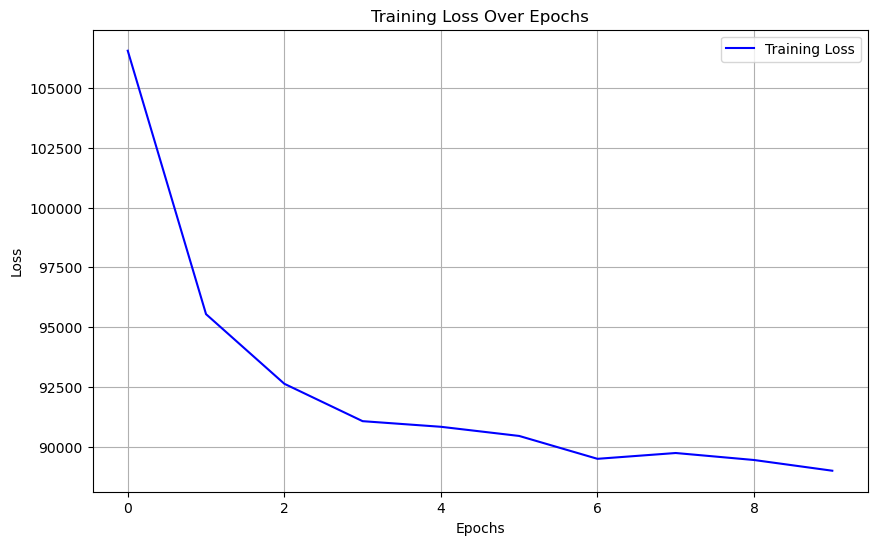

In [244]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# ===================== Data Preprocessing =====================
# Scale the data
# scaler = MinMaxScaler(feature_range=(0, 1))
# X_scaled = scaler.fit_transform(X)

# Reshape input for LSTM (samples, timesteps, features)
X_reshaped = X.reshape((X.shape[0], n_weeks, 1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, shuffle=False)

# ===================== LSTM Model =====================
# Define the LSTM model
model = Sequential()
# model.add(Masking(mask_value=mask_value, input_shape=(n_weeks, 1)))  # Masking layer
model.add(Masking(mask_value=-999.))

model.add(LSTM(50, activation='relu'))  # LSTM layer with 50 units
model.add(Dense(1))  # Output layer for prediction
# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# ===================== Evaluation =====================
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {rmse:.2f}")

# Calculate Sign Agreement Accuracy
def sign_agreement(y_true, y_pred):
    if isinstance(y_true, pd.Series):
        y_true = y_true.values
    if isinstance(y_pred, pd.Series):
        y_pred = y_pred.values
    true_sign = np.sign(y_true)
    pred_sign = np.sign(y_pred)
    agreement = np.mean(true_sign == pred_sign) * 100
    return agreement

# Plot Training Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [245]:
sign_accuracy = sign_agreement(y_test,y_pred)
print(f"Sign Agreement Accuracy: {sign_accuracy:.2f}%")

Sign Agreement Accuracy: 48.92%


<Axes: >

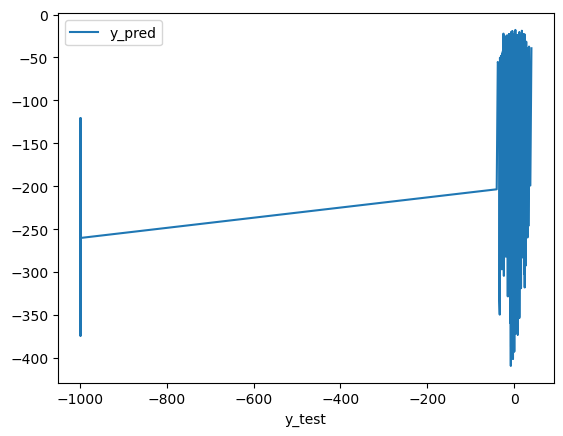

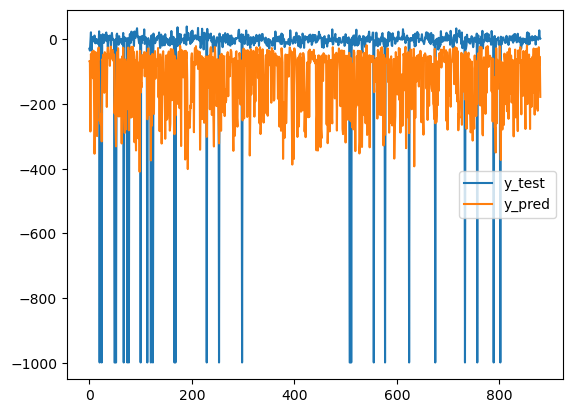

In [247]:
# crete df from y_test and y_pred
df = pd.DataFrame({'y_test':y_test.flatten(), 'y_pred':y_pred.flatten()})
df.set_index('y_test').sort_index().plot()
df.plot()

In [249]:
mask = tf.cast(X_reshaped != -999., tf.float32)
np.mean(mask)
input_layer
# X_reshaped

<KerasTensor: shape=(None, 5, 1) dtype=float32 (created by layer 'input_4')>

Epoch 1/10
111/111 [==============================] - 4s 8ms/step - loss: 106479.3906
Epoch 2/10
111/111 [==============================] - 1s 8ms/step - loss: 97630.9453
Epoch 3/10
111/111 [==============================] - 1s 8ms/step - loss: 94523.5938
Epoch 4/10
111/111 [==============================] - 1s 8ms/step - loss: 91926.0000
Epoch 5/10
111/111 [==============================] - 1s 7ms/step - loss: 90344.4141
Epoch 6/10
111/111 [==============================] - 1s 7ms/step - loss: 89999.9922
Epoch 7/10
111/111 [==============================] - 1s 7ms/step - loss: 89287.7266
Epoch 8/10
111/111 [==============================] - 1s 7ms/step - loss: 88479.0703
Epoch 9/10
111/111 [==============================] - 1s 7ms/step - loss: 88330.8438
Epoch 10/10
28/28 [==============================] - 0s 3ms/step
Root Mean Squared Error: 207.51


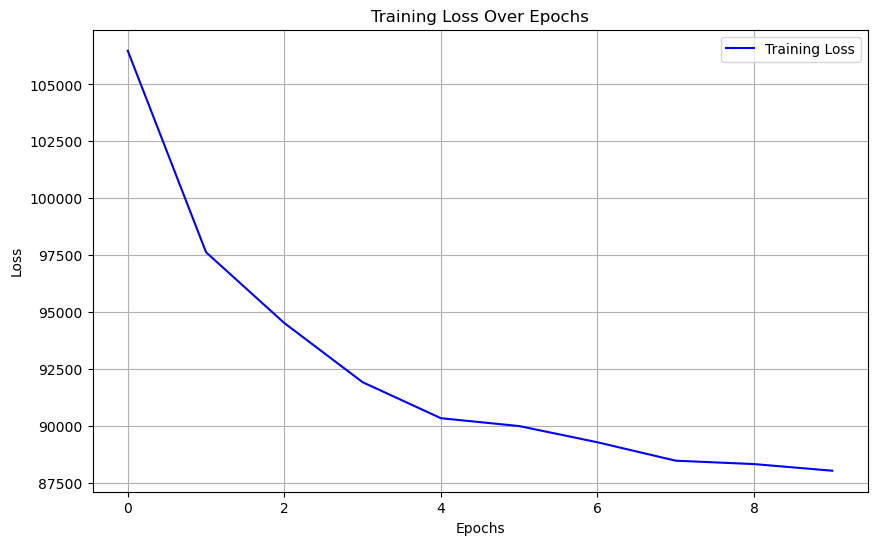

In [250]:
import tensorflow as tf

# Create a mask where mask_value matches -999
mask = tf.cast(X_reshaped != -999., tf.float32)

# Pass mask during LSTM input
input_layer = tf.keras.Input(shape=(n_weeks, 1))
masked_input = tf.keras.layers.Masking(mask_value=-999)(input_layer)
lstm_output = tf.keras.layers.LSTM(50, activation='relu')(masked_input)
output_layer = tf.keras.layers.Dense(1)(lstm_output)

# Define the model
model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {rmse:.2f}")

# Plot Training Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


In [254]:
y_test
np.mean(y_pred)

-117.38594

In [255]:
import tensorflow as tf

# Define the model with Masking
input_layer = tf.keras.Input(shape=(n_weeks, 1))
masked_input = tf.keras.layers.Masking(mask_value=-999.)(input_layer)
lstm_output = tf.keras.layers.LSTM(50, activation='relu')(masked_input)
output_layer = tf.keras.layers.Dense(1)(lstm_output)
model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Create dummy inputs with a masked value (-999)
X_dummy = np.array([
    [[1], [2], [3], [-999], [-999]],  # Masked values
    [[4], [5], [6], [7], [8]]         # No masked values
], dtype=np.float32)

y_dummy = np.array([10, 20], dtype=np.float32)  # Dummy target values

# Use GradientTape to capture gradients
with tf.GradientTape() as tape:
    tape.watch(X_dummy)  # Watch input for gradient computation
    preds = model(X_dummy, training=True)  # Forward pass
    loss = tf.keras.losses.mean_squared_error(y_dummy, preds)  # Compute loss

# Compute gradients with respect to the input
gradients = tape.gradient(loss, X_dummy)

print("Predictions:", preds.numpy())
print("Gradients:", gradients.numpy())


ValueError: Passed in object [[[   1.]
  [   2.]
  [   3.]
  [-999.]
  [-999.]]

 [[   4.]
  [   5.]
  [   6.]
  [   7.]
  [   8.]]] of type 'ndarray', not tf.Tensor or tf.Variable or ExtensionType.